In [ ]:
# Imports principais
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import numpy as np
import matplotlib.pyplot as plt

# Versão do TF (só para conferência no print)
print("TensorFlow:", tf.__version__)

# Carregar o conjunto de dados MNIST (imagens 28x28 de dígitos 0-9)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Dimensões
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

TensorFlow: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (60000, 28, 28) y_train: (60000,)
X_test: (10000, 28, 28) y_test: (10000,)


In [ ]:
# Normalizar pixels para [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

# Flatten: 28x28 -> 784
X_train = X_train.reshape(-1, 28 * 28)
X_test  = X_test.reshape(-1, 28 * 28)

# One-hot encoding dos rótulos
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

print("Após preprocessamento:")
print("X_train:", X_train.shape, "y_train_cat:", y_train_cat.shape)
print("X_test:", X_test.shape, "y_test_cat:", y_test_cat.shape)


Após preprocessamento:
X_train: (60000, 784) y_train_cat: (60000, 10)
X_test: (10000, 784) y_test_cat: (10000, 10)


In [ ]:
model = models.Sequential([
    layers.Input(shape=(28 * 28,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Treino
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.1,     # 10% do treino para validação
    epochs=10,                # aumentar para 15-20 (melhor acurácia)
    batch_size=128,
    verbose=1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8058 - loss: 0.6322 - val_accuracy: 0.9642 - val_loss: 0.1191
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9541 - loss: 0.1550 - val_accuracy: 0.9748 - val_loss: 0.0857
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9683 - loss: 0.1068 - val_accuracy: 0.9780 - val_loss: 0.0739
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9743 - loss: 0.0834 - val_accuracy: 0.9780 - val_loss: 0.0668
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9794 - loss: 0.0680 - val_accuracy: 0.9820 - val_loss: 0.0629
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9815 - loss: 0.0580 - val_accuracy: 0.9808 - val_loss: 0.0709
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9842 - loss: 0.0497 - val_accuracy: 0.9793 - val_loss: 0.0671
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9861 - loss: 0.0453 - val_accuracy: 0

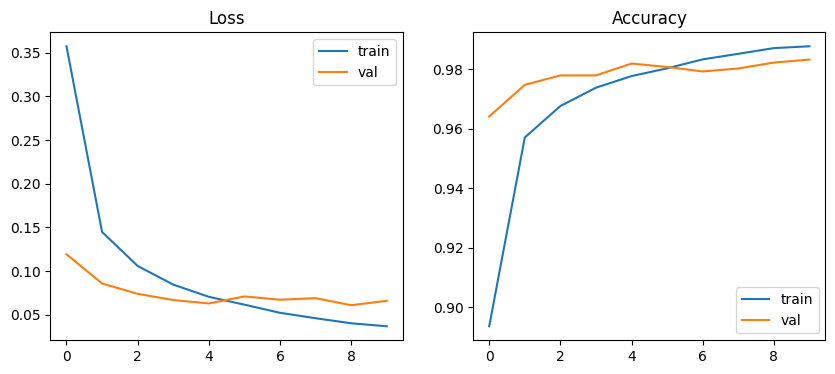

In [ ]:
# Visualizar curva de aprendizado
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()
plt.show()


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Acurácia em teste: {test_acc:.4f}")


Acurácia em teste: 0.9805


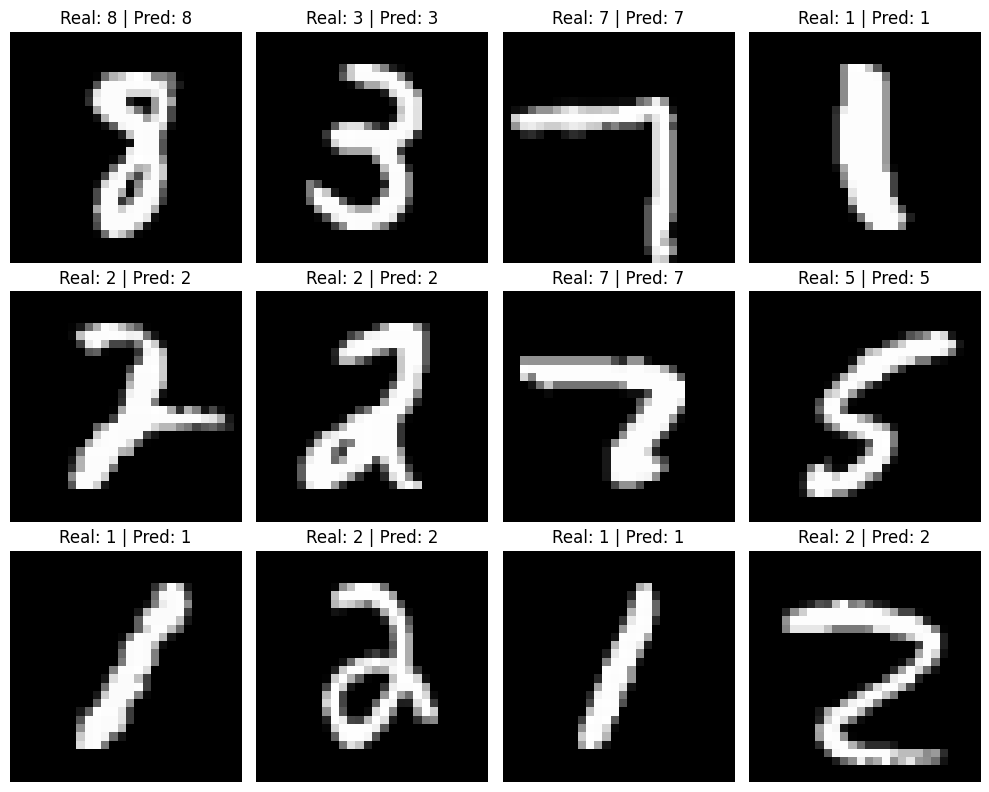

In [ ]:
# Selecionar alguns exemplos aleatórios
indices = np.random.choice(len(X_test), size=12, replace=False)
samples = X_test[indices]
labels_true = y_test[indices]

# Previsões
probs = model.predict(samples, verbose=0)
labels_pred = probs.argmax(axis=1)

# Plotar
plt.figure(figsize=(10,8))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i+1)
    plt.imshow(samples[i].reshape(28,28), cmap="gray")
    plt.title(f"Real: {labels_true[i]} | Pred: {labels_pred[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()
